In [1]:
from nanoplasma_analysis_final import NanoPlasmaRun
%matplotlib inline

#### Load constants ####
import scipy.constants as sc

from numpy import *

import matplotlib
from matplotlib.pyplot import *
from matplotlib.colors import LogNorm
import glob
import os

import sys


import adios2


run = NanoPlasmaRun(
    path="/p/scratch/pwfa-trojan/medina2/2026_nanoplasma/004_Neutral_Smallsteps/simOutput",
    laser_peak_at_target=89603
)
## Sims without laser
path = ("/p/scratch/pwfa-trojan/medina2/2026_nanoplasma/004_Neutral_Smallsteps/simOutput")
files = glob.glob(path + "/openPMD/" + "*.bp5")

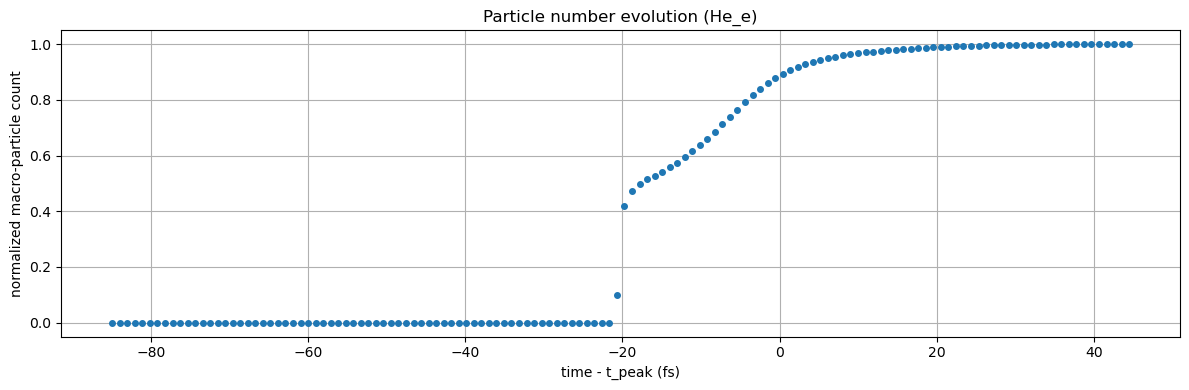

In [2]:
run.plot_particle_number(species="He_e")

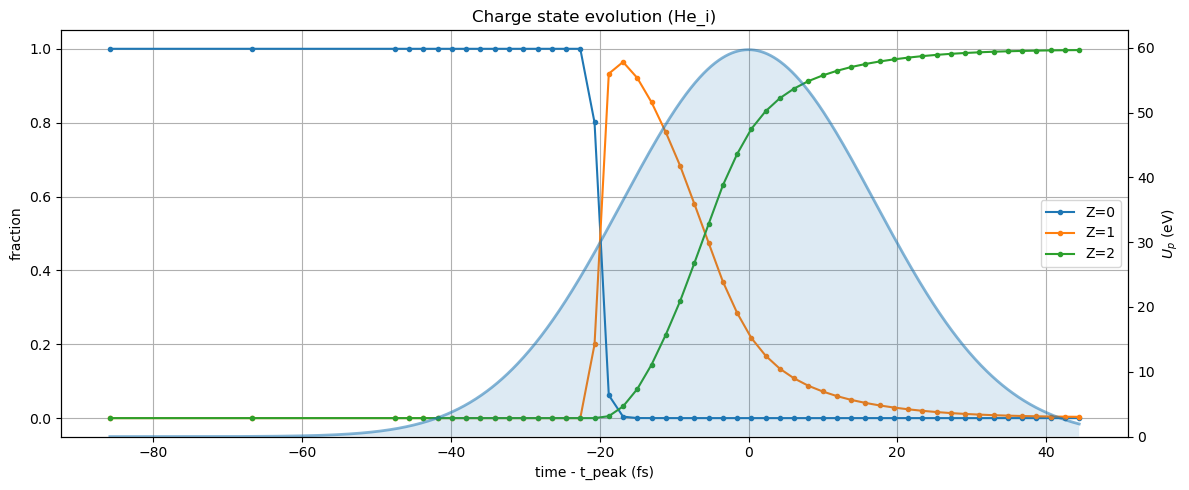

In [3]:
run.plot_charge_state_evolution(
    ion_species="He_i", Zmax=2,
    show_laser_envelope=True,
    tau_fwhm_fs=40.0, I0_Wcm2=1e15, lambda_um=0.8
)


In [ ]:
from nanoplasma_analysis_final import extract_step_from_filename
laser_peak_at_target=89603

base_out = "/p/scratch/pwfa-trojan/medina2/notebooks/bilder"
# extract run name from simulation directory
run_name = os.path.basename(os.path.dirname(os.path.normpath(path)))

# get dt_fs once (from first file)
with adios2.Stream(files[0], "r") as f:
    for _ in f.steps():
        t0 = extract_step_from_filename(files[0])
        dt = f.read_attribute(f"/data/{t0}/dt")
        unit_time = f.read_attribute(f"/data/{t0}/unit_time")
dt_fs = dt * unit_time * 1e15

for i in np.arange(len(files)):
    it = extract_step_from_filename(files[i])
    t_rel_fs = (it - laser_peak_at_target) * dt_fs
    png_path = os.path.join( base_out, f"{run_name}_frame_{i:05d}_{t_rel_fs:+06.0f}fs.png")    
    run.plot_field_e_i_maps(
        file_index=i,
        y_nm=300.0,
        I0_Wcm2=4e14,
        zoom_ions=True,
        ion_zoom_pad_nm=50.0,
        savepath=png_path,
        #ion_charge_density_field="He_i_all_boundElectronDensity" #defaul        ion_charge_density_field: str = "He_i_all_density",
    )
    


In [ ]:
run.plot_laser_envelope_and_electron_yield(
    species="He_e",
    tau_fwhm_fs=40.0,
    I0_Wcm2=4e14,
    lambda_um=0.8
)


In [ ]:
run.plot_kinetic_energy_spectra(
    species="He_i",
    file_indices="all",
    bins=(0, 100, 100),
    normalize=False,logy=True
)


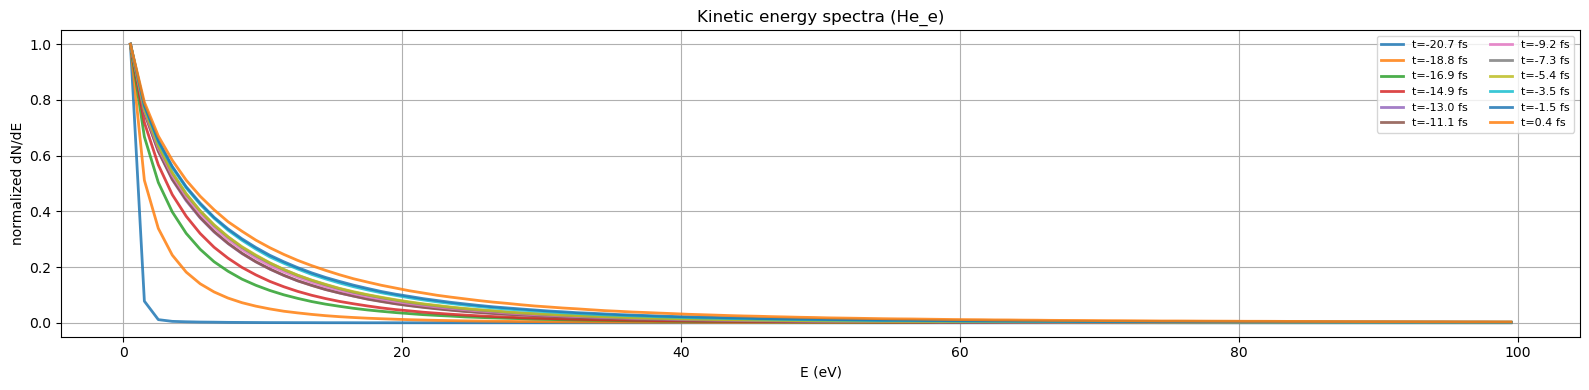

In [12]:
run.plot_kinetic_energy_spectra(
    species="He_e",
    file_indices=[-]#"all",
    bins=(0, 100, 100),
    normalize=True,logy=False
)


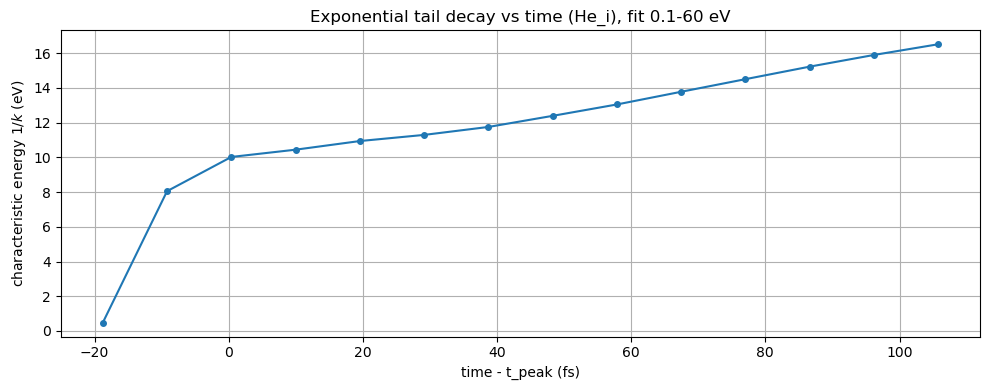

(array([-18.78167385,  -9.20065368,   0.3803665 ,   9.96138668,
         19.54240686,  29.12342703,  38.70444721,  48.28546739,
         57.86648757,  67.44750774,  77.02852792,  86.6095481 ,
         96.19056828, 105.77158846]),
 array([ 0.47670858,  8.05210516, 10.02292543, 10.44132982, 10.93940715,
        11.29282771, 11.75105465, 12.39061513, 13.04681486, 13.77754067,
        14.50381947, 15.2256427 , 15.89860902, 16.51519692]))

In [29]:
run.plot_tail_decay_vs_time(
    species="He_i",
    Emin_eV=0.1, Emax_eV=60,
    Ebins_max_eV=200.0, Nbins=400,
    plot_characteristic_energy=True   # set True for 1/k
)


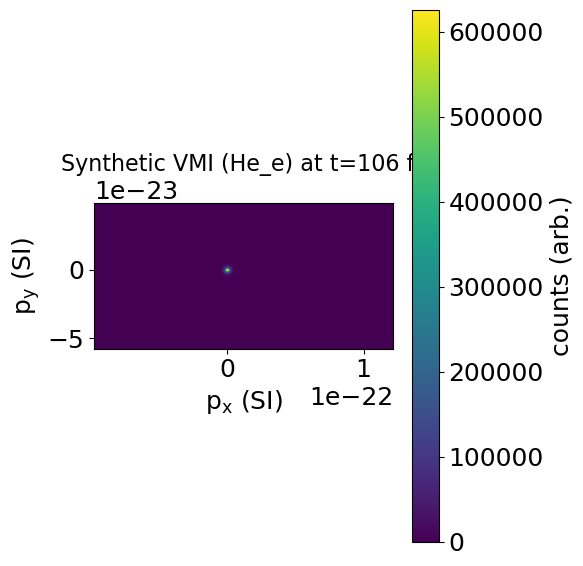

In [14]:
run.plot_vmi(species="He_e", file_index=-1, plane=("x","y"), Nbins=200)


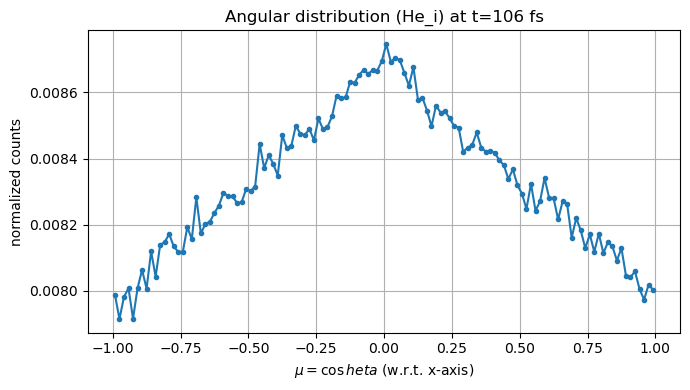

(array([-0.99166667, -0.975     , -0.95833333, -0.94166667, -0.925     ,
        -0.90833333, -0.89166667, -0.875     , -0.85833333, -0.84166667,
        -0.825     , -0.80833333, -0.79166667, -0.775     , -0.75833333,
        -0.74166667, -0.725     , -0.70833333, -0.69166667, -0.675     ,
        -0.65833333, -0.64166667, -0.625     , -0.60833333, -0.59166667,
        -0.575     , -0.55833333, -0.54166667, -0.525     , -0.50833333,
        -0.49166667, -0.475     , -0.45833333, -0.44166667, -0.425     ,
        -0.40833333, -0.39166667, -0.375     , -0.35833333, -0.34166667,
        -0.325     , -0.30833333, -0.29166667, -0.275     , -0.25833333,
        -0.24166667, -0.225     , -0.20833333, -0.19166667, -0.175     ,
        -0.15833333, -0.14166667, -0.125     , -0.10833333, -0.09166667,
        -0.075     , -0.05833333, -0.04166667, -0.025     , -0.00833333,
         0.00833333,  0.025     ,  0.04166667,  0.05833333,  0.075     ,
         0.09166667,  0.10833333,  0.125     ,  0.1

In [6]:
run.plot_angular_distribution(species="He_i", file_index=-1, axis="x")


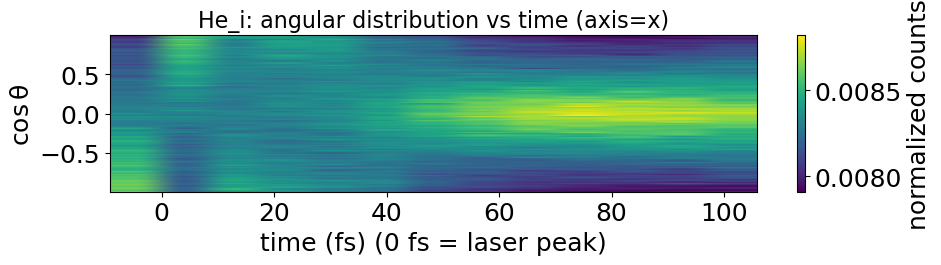

(array([ -9.20065368,   0.3803665 ,   9.96138668,  19.54240686,
         29.12342703,  38.70444721,  48.28546739,  57.86648757,
         67.44750774,  77.02852792,  86.6095481 ,  96.19056828,
        105.77158846]),
 array([[0.00863288, 0.00820367, 0.00839679, ..., 0.00793374, 0.00796828,
         0.00798714],
        [0.00855433, 0.00819914, 0.00847777, ..., 0.00792998, 0.00790856,
         0.00791383],
        [0.00862965, 0.00819536, 0.00852814, ..., 0.00799786, 0.00797505,
         0.00798068],
        ...,
        [0.00806103, 0.00851779, 0.00839671, ..., 0.00796158, 0.00792846,
         0.00797242],
        [0.00798583, 0.00857957, 0.0084343 , ..., 0.00791458, 0.00798256,
         0.00801742],
        [0.00805347, 0.00859926, 0.00837192, ..., 0.00801501, 0.00793041,
         0.00800258]], shape=(120, 13)))

In [4]:
run.plot_angular_distribution_vs_time(species="He_i", axis="x", skip_before_fs=-17)

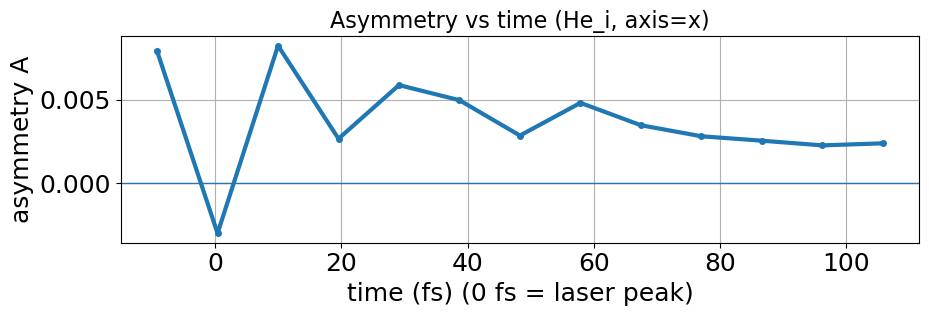

(array([ -9.20065368,   0.3803665 ,   9.96138668,  19.54240686,
         29.12342703,  38.70444721,  48.28546739,  57.86648757,
         67.44750774,  77.02852792,  86.6095481 ,  96.19056828,
        105.77158846]),
 array([ 0.00790874, -0.00298976,  0.00822911,  0.00266773,  0.00587574,
         0.00497007,  0.00285766,  0.00481216,  0.00347352,  0.00281459,
         0.00254976,  0.00227007,  0.00239298]))

In [5]:
run.plot_asymmetry_vs_time(species="He_i", axis="x",skip_before_fs=-17)

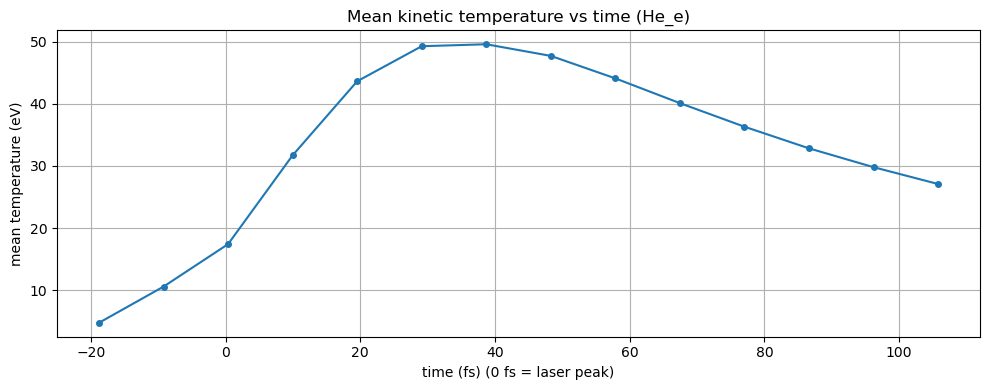

(array([-18.78167385,  -9.20065368,   0.3803665 ,   9.96138668,
         19.54240686,  29.12342703,  38.70444721,  48.28546739,
         57.86648757,  67.44750774,  77.02852792,  86.6095481 ,
         96.19056828, 105.77158846]),
 array([ 4.76043405, 10.58458127, 17.41995646, 31.71424715, 43.63242058,
        49.27754156, 49.59347652, 47.72269197, 44.1012017 , 40.11785657,
        36.32383809, 32.84203195, 29.81100048, 27.101539  ]))

In [3]:
run.plot_mean_temperature_vs_time(species="He_e")

In [14]:
run.make_field_e_i_gif(
    out_gif="002_field_e_i_maps.gif",
    y_nm=300.0,
    I0_Wcm2=4e14,
    zoom_ions=True,
    ion_zoom_pad_nm=50.0,
    ion_charge_density_field="He_i_all_boundElectronDensity",
    fps=3,
    every=1
)


'/p/scratch/pwfa-trojan/medina2/notebooks/002_field_e_i_maps.gif'